# Placement Prediction using Machine Learning 

This project predicts whether a student will be placed based on CGPA and IQ using different Machine Learning classification algorithms.

Algorithms Used:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Linear SVM
- Kernel SVM (RBF)
- Decision Tree
- Random Forest

# Import Libraries

In [111]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
dataset=pd.read_csv('placement-dataset.csv')
dataset=dataset.drop(columns=['Unnamed: 0'])
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values


# Data Preprocessing

# Split the data into Test and Training set

In [118]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20, random_state=42)

In [119]:
print(X_test)

[[  7.5 130. ]
 [  8.3 168. ]
 [  6.3 127. ]
 [  6.   66. ]
 [  7.5  61. ]
 [  4.6 146. ]
 [  4.9 120. ]
 [  4.9 196. ]
 [  6.   45. ]
 [  6.8 123. ]
 [  4.  100. ]
 [  7.6 128. ]
 [  4.9  61. ]
 [  6.  149. ]
 [  7.3  86. ]
 [  5.8 142. ]
 [  4.9 155. ]
 [  7.3  50. ]
 [  5.4 139. ]
 [  3.9 109. ]]


# Feature Scaling

In [121]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


# Helper Functions

In [122]:
from sklearn.metrics import accuracy_score,confusion_matrix
def evaluate_model(model,X_train,y_train,X_test,y_test):
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    cm=confusion_matrix(y_test,y_pred)
    return accuracy,cm 

In [125]:
from matplotlib.colors import ListedColormap
import numpy as np
def plot_decision_boundary(model,title):
    X_set, y_set = X_train, y_train

    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:,0].min()-1, stop=X_set[:,0].max()+1, step=0.01),
        np.arange(start=X_set[:,1].min()-1, stop=X_set[:,1].max()+1, step=0.01)
    )

    plt.contourf(
        X1,
        X2,
        model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.75,
        cmap=ListedColormap(('red','green'))
    )

    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            c=ListedColormap(('red','green'))(i),
            label=j
        )

    plt.title(title)
    plt.xlabel("CGPA")
    plt.ylabel("IQ")
    plt.legend()
    plt.show()

In [126]:
results=[]

# Logistic Regression

In [127]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
accuracy,cm=evaluate_model(
    lr,
    X_train,
    y_train,
    X_test,
    y_test
)
results.append([
    "Logistic Regression",
    accuracy
])
print(accuracy)
print(cm)

0.85
[[9 1]
 [2 8]]


C:\Users\krish\AppData\Local\Temp\ipykernel_20856\1782367925.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


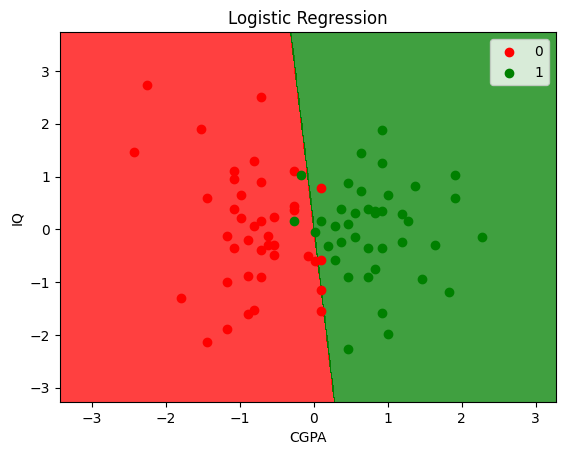

In [128]:
plot_decision_boundary(
    lr,
    "Logistic Regression"
)

# KNN

In [129]:
from sklearn.neighbors import KNeighborsClassifier
neigh=KNeighborsClassifier(n_neighbors=5)
accuracy,cm=evaluate_model(
    neigh,
    X_train,
    y_train,
    X_test,
    y_test
)
results.append([
    "KNN",
    accuracy
])
print(accuracy)
print(cm)


0.9
[[10  0]
 [ 2  8]]


C:\Users\krish\AppData\Local\Temp\ipykernel_20856\1782367925.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


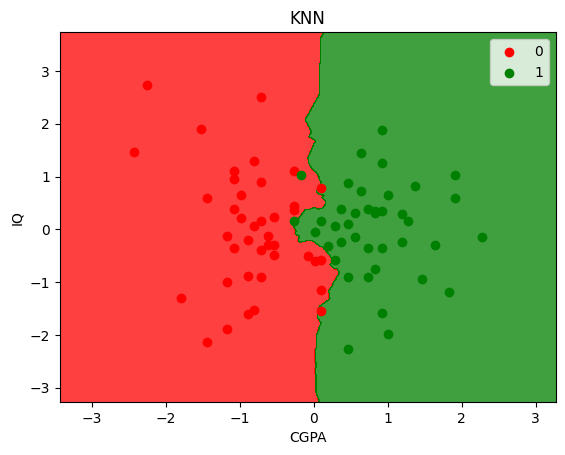

In [130]:
plot_decision_boundary(
    neigh,
    "KNN"
)

# Linear SVM

In [131]:
from sklearn.svm import LinearSVC
sv=LinearSVC()
accuracy,cm=evaluate_model(sv, X_train,
    y_train,
    X_test,
    y_test)
results.append([
    "Linear SVM",
    accuracy
])
print(accuracy)
print(cm)

0.85
[[9 1]
 [2 8]]


C:\Users\krish\AppData\Local\Temp\ipykernel_20856\1782367925.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


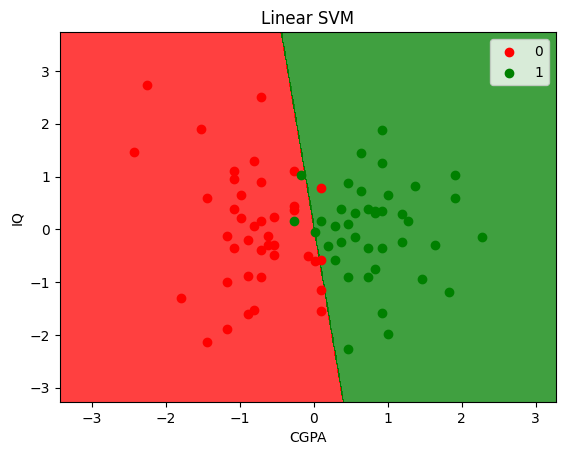

In [132]:
plot_decision_boundary(
    sv,
    "Linear SVM"
)

# kernel SVM

In [133]:
from sklearn.svm import SVC
k_svc=SVC(kernel='rbf')
accuracy,cm=evaluate_model(k_svc, X_train,
    y_train,
    X_test,
    y_test)
results.append([
    "kernel SVM",
    accuracy
])
print(accuracy)
print(cm)

0.85
[[9 1]
 [2 8]]


C:\Users\krish\AppData\Local\Temp\ipykernel_20856\1782367925.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


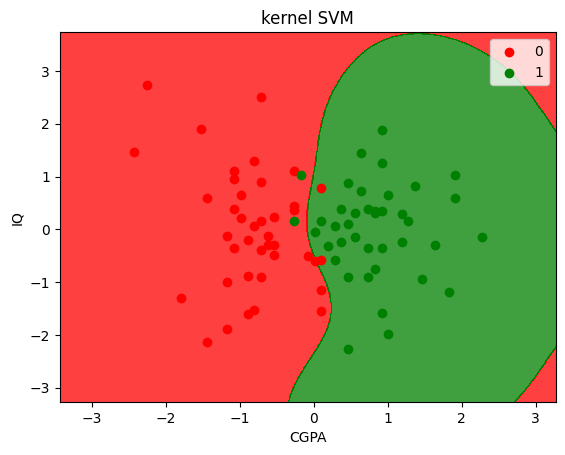

In [134]:
plot_decision_boundary(
    k_svc,
    "kernel SVM"
)

# Decision Tree

In [135]:
from sklearn.tree import DecisionTreeClassifier
dec=DecisionTreeClassifier()
accuracy,cm=evaluate_model(dec, X_train,
    y_train,
    X_test,
    y_test)
results.append([
    "Decision Tree",
    accuracy
])
print(accuracy)
print(cm)

0.9
[[10  0]
 [ 2  8]]


C:\Users\krish\AppData\Local\Temp\ipykernel_20856\1782367925.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


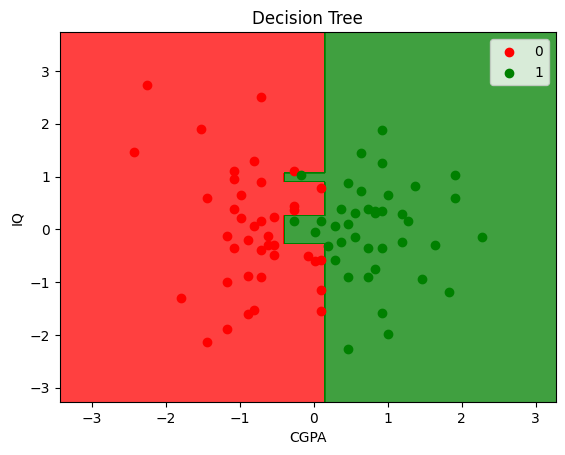

In [136]:
plot_decision_boundary(
    dec,
    "Decision Tree"
)

# Random Forest

In [137]:
from sklearn.ensemble import RandomForestClassifier
random=RandomForestClassifier(n_estimators=100)
accuracy,cm=evaluate_model(random, X_train,
    y_train,
    X_test,
    y_test)
results.append([
    "Random Forest",
    accuracy
])
print(accuracy)
print(cm)

0.9
[[10  0]
 [ 2  8]]


C:\Users\krish\AppData\Local\Temp\ipykernel_20856\1782367925.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


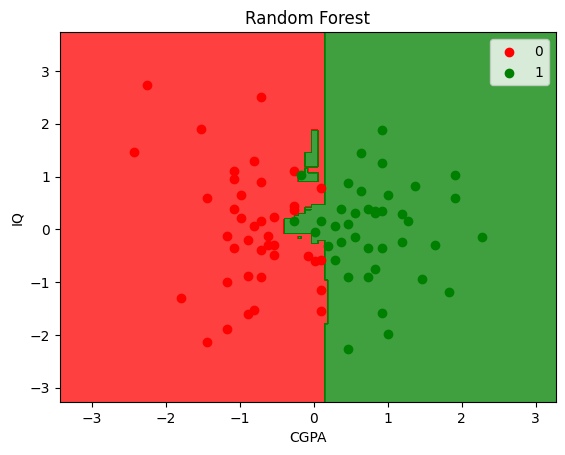

In [138]:
plot_decision_boundary(
    random,
    "Random Forest"
)

# Comparison table

In [140]:
result_df=pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

result_df

,Model,Accuracy
0,Logistic Regression,0.85
1,KNN,0.90
2,Linear SVM,0.85
3,kernel SVM,0.85
4,Decision Tree,0.90
5,Random Forest,0.90


# Plot the comparison graph

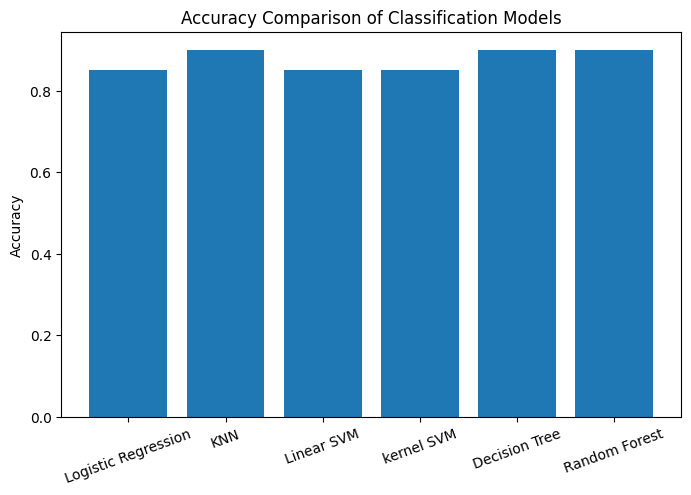

In [141]:
plt.figure(figsize=(8,5))
plt.bar(result_df["Model"], result_df["Accuracy"])
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Models")
plt.show()

# Predict for a New Student

In [144]:
new_student = np.array([[8.5,120]])
new_student = sc.transform(new_student)
prediction = random.predict(new_student)

if prediction[0] == 1:
    print("The student is likely to be Placed.")
else:
    print("The student is likely to be Not Placed.")

The student is likely to be Placed.


In [145]:
import joblib

# Save the trained Random Forest model
joblib.dump(random, "placement_model.pkl")

# Save the fitted StandardScaler
joblib.dump(sc, "scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


# Conclusion


Among the evaluated classification algorithms:

- Logistic Regression achieved an accuracy of 85%.
- KNN achieved an accuracy of 90%.
- Linear SVM achieved an accuracy of 85%.
- Kernel SVM achieved an accuracy of 85%.
- Decision Tree achieved an accuracy of 90%.
- Random Forest achieved an accuracy of 90%.

KNN, Decision Tree, and Random Forest performed best on this dataset with an accuracy of 90%. Logistic Regression and SVM-based models achieved slightly lower accuracy because they learned simpler decision boundaries.